# HIGGS — GPU Hızlandırmalı Eğitim (RTX 3060 / CUDA)

| Model | GPU Desteği | Notlar |
|-------|------------|--------|
| **XGBoost** | `device='cuda'` + `tree_method='hist'` | Doğal CUDA desteği |
| **PyTorch MLP** | Tam GPU eğitimi | Sklearn-uyumlu sarmalayıcı, BatchNorm + Dropout + Cosine LR |
| **KNN** | CPU (`n_jobs=-1`) | Odev gereksinimi: n_neighbors=3-11, kucuk alt-orneklem uzerinde |
| **SVM** | CPU (`n_jobs` ic CV) | Odev gereksinimi: C=[0.1,1,10], kernel=[linear,rbf], kucuk alt-orneklem uzerinde |

> KNN ve SVM, O(n^2) karmasiklikari nedeniyle `KNN_SVM_N_SAMPLES` ile sinirlandirilan ayri (daha kucuk) bir alt-orneklem uzerinde calistirilir. XGBoost ve MLP tam `N_SAMPLES` uzerinde calisir.

In [1]:
%matplotlib inline

import json
import os
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)


def AUC_SCORER(estimator, X, y):
    # sklearn 1.8 uyumlu callable scorer
    return roc_auc_score(y, estimator.predict_proba(X)[:, 1])

## GPU Kontrolü

In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU      : {props.name}')
    print(f'VRAM     : {props.total_memory / 1e9:.1f} GB')
    print(f'CUDA ver : {torch.version.cuda}')
    print(f'PyTorch  : {torch.__version__}')
else:
    print('UYARI: CUDA bulunamadi, CPU kullanilacak.')

Device   : cuda
GPU      : NVIDIA GeForce RTX 3060
VRAM     : 12.9 GB
CUDA ver : 12.4
PyTorch  : 2.6.0+cu124


## Ayarlar

`N_SAMPLES` — veri büyüklüğü ve beklenen süre (RTX 3060, 360 toplam fit):

| N_SAMPLES | XGBoost/fit | Toplam süre |
|-----------|------------|-------------|
| `500_000` | ~10s | ~1.5 saat |
| `1_000_000` | ~20s | ~3 saat |
| `2_000_000` | ~40s | ~5-6 saat |
| **`2_500_000`** | **~50s** | **~7-8 saat** ✓ |
| `3_000_000` | ~65s | ~9-10 saat |

> Bottleneck: 240 XGBoost fit. MLP çok küçük ağ olduğu için sürenin ~%10'u.

In [3]:
SEED       = 42
N_SAMPLES  = int(os.environ.get('HIGGS_N', 100_000))   # DENEME modu: hizli kosu
HIGGS_PATH = os.environ.get('HIGGS_PATH', 'data/higgs/HIGGS.csv.gz')
K_GRID         = [10, 15]
KNN_SVM_N_SAMPLES = int(os.environ.get('HIGGS_KNN_SVM_N', 2_000))   # KNN/SVM icin alt-orneklem
OUTER      = 5
INNER      = 3

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

FEATURES = [
    'lepton_pT', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude',
    'missing_energy_phi', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_b_tag',
    'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_b_tag', 'jet3_pt', 'jet3_eta',
    'jet3_phi', 'jet3_b_tag', 'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_b_tag',
    'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb'
]

print(f'HIGGS_PATH : {HIGGS_PATH}')
print(f'Dosya var  : {os.path.exists(HIGGS_PATH)}')
print(f'N_SAMPLES  : {N_SAMPLES:,}')
print(f'Device     : {DEVICE}')

HIGGS_PATH : data/higgs/HIGGS.csv.gz
Dosya var  : True
N_SAMPLES  : 100,000
Device     : cuda


## Yardımcı Fonksiyonlar

In [4]:
HIGGS_TOTAL_ROWS = 11_000_000  # HIGGS.csv.gz toplam satir sayisi (ilerleme % icin)

# HIGGS satirlari karisik (i.i.d.) oldugundan, ilk ~3*N satirdan rastgele N ornek
# secmek tum 11M satiri okumaya gore istatistiksel olarak esdegerdir ama cok daha hizlidir.
# Gercek teslimde tam rastgele ornekleme istenirse False yapip tum dosya okunabilir.
HIZLI_OKUMA = True

def veri_yukle(n, path, seed):
    if path and os.path.exists(path):
        print(f'[veri] Gercek HIGGS okunuyor: {path}')

        if HIZLI_OKUMA:
            # Yalnizca gerekli kadar satir oku (hizli). Bir miktar fazla okuyup
            # icinden n tanesini rastgele sec ki cesitlilik korunsun.
            okunacak = min(int(n * 3), HIGGS_TOTAL_ROWS)
            print(f'[veri] HIZLI mod: ilk {okunacak:,} satir okunuyor...')
            df = pd.read_csv(path, header=None, names=['label'] + FEATURES,
                             nrows=okunacak)
            return df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

        # Tam mod: tum dosyayi parca parca oku, ilerleme yuzdesi goster
        parcalar = []
        with pd.read_csv(path, header=None, names=['label'] + FEATURES,
                          chunksize=200_000) as okuyucu:
            pbar = tqdm(okuyucu, total=HIGGS_TOTAL_ROWS // 200_000 + 1,
                         desc='[veri] okuma', unit='parca')
            for parca in pbar:
                parcalar.append(parca)
                okunan = sum(len(p) for p in parcalar)
                pbar.set_postfix_str(f'{100 * okunan / HIGGS_TOTAL_ROWS:.1f}%')
        df = pd.concat(parcalar, ignore_index=True)
        return df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    print(f'[veri] Sentetik veri uretiliyor (n={n})')
    from sklearn.datasets import make_classification
    rng = np.random.default_rng(seed)
    X, y = make_classification(n_samples=n, n_features=28, n_informative=14,
        n_redundant=6, weights=[0.47, 0.53], flip_y=0.08, class_sep=0.9,
        random_state=seed)
    for j in [0, 3, 5, 9, 13, 17, 21, 22, 23, 24, 25, 26, 27]:
        X[:, j] = np.expm1(np.abs(X[:, j]) / 2.0)
    for j in [0, 5, 21, 25]:
        idx = rng.choice(n, size=max(1, n // 100), replace=False)
        X[idx, j] *= rng.uniform(8, 15, size=len(idx))
    df = pd.DataFrame(X, columns=FEATURES)
    df.insert(0, 'label', y.astype(int))
    return df


def metrikler(y_true, y_pred, y_skor):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_true, y_skor),
    }


def skor_al(model, X):
    return (model.predict_proba(X)[:, 1]
            if hasattr(model, 'predict_proba')
            else model.decision_function(X))

## PyTorch MLP — Sklearn Uyumlu GPU Sarmalayıcısı

Mimari: `Linear → BatchNorm → ReLU → Dropout` bloklarından oluşuyor.  
Optimizer: **Adam** + **Cosine Annealing LR**.  
Early stopping ile en iyi ağırlıklar saklanıyor.

In [5]:
class TorchMLP(BaseEstimator, ClassifierMixin):
    """Sklearn-uyumlu PyTorch MLP (GPU destekli, nested-CV icin).

    Odev gereksinimi: hidden_layer_sizes=[(50,),(100,)], activation=['relu','tanh'].
    Bu sarmalayici sklearn MLPClassifier ile ayni API'yi (hidden_sizes/activation)
    sunar; fark, egitimin GPU uzerinde PyTorch ile yapilmasidir.
    """

    _estimator_type = 'classifier'   # sklearn 1.8 icin explicit tanimlama

    _AKTIVASYONLAR = {'relu': nn.ReLU, 'tanh': nn.Tanh}

    def __init__(self, hidden_sizes=(128, 64), activation='relu', lr=1e-3,
                 epochs=150, batch_size=4096, dropout=0.3, patience=15, verbose=True):
        self.hidden_sizes = hidden_sizes
        self.activation   = activation
        self.lr           = lr
        self.epochs       = epochs
        self.batch_size   = batch_size
        self.dropout      = dropout
        self.patience     = patience
        self.verbose      = verbose

    def _make_net(self, n_in):
        akt = self._AKTIVASYONLAR[self.activation]
        layers, in_f = [], n_in
        for h in self.hidden_sizes:
            layers += [
                nn.Linear(in_f, h),
                nn.BatchNorm1d(h),
                akt(),
                nn.Dropout(self.dropout),
            ]
            in_f = h
        layers.append(nn.Linear(in_f, 1))
        return nn.Sequential(*layers)

    def fit(self, X, y):
        dev = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.classes_ = np.unique(y)
        net = self._make_net(X.shape[1]).to(dev)

        Xt = torch.from_numpy(X.astype(np.float32))
        yt = torch.from_numpy(y.astype(np.float32))
        loader = DataLoader(
            TensorDataset(Xt, yt),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=(dev == 'cuda'),
            num_workers=0,
        )

        opt   = torch.optim.Adam(net.parameters(), lr=self.lr, weight_decay=1e-5)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.epochs)
        crit  = nn.BCEWithLogitsLoss()

        best_loss, wait = float('inf'), 0
        best_w = {k: v.cpu().clone() for k, v in net.state_dict().items()}

        pbar = tqdm(
            range(self.epochs),
            desc=f'MLP [{dev.upper()}]',
            unit='ep',
            leave=False,
            disable=not self.verbose,
            dynamic_ncols=True,
        )

        net.train()
        for _ in pbar:
            ep_loss = 0.0
            for Xb, yb in loader:
                Xb = Xb.to(dev, non_blocking=True)
                yb = yb.to(dev, non_blocking=True)
                opt.zero_grad(set_to_none=True)
                loss = crit(net(Xb).squeeze(1), yb)
                loss.backward()
                opt.step()
                ep_loss += loss.item() * len(Xb)
            sched.step()
            ep_loss /= len(Xt)

            if ep_loss < best_loss - 1e-5:
                best_loss, wait = ep_loss, 0
                best_w = {k: v.cpu().clone() for k, v in net.state_dict().items()}
            else:
                wait += 1
                if wait >= self.patience:
                    pbar.set_postfix_str(f'erken_dur | loss={ep_loss:.4f} best={best_loss:.4f}')
                    break

            pbar.set_postfix({
                'loss'    : f'{ep_loss:.4f}',
                'best'    : f'{best_loss:.4f}',
                'patience': f'{wait}/{self.patience}',
            })

        net.load_state_dict(best_w)
        self.net_ = net.eval()
        self.dev_ = dev
        return self

    def predict_proba(self, X):
        with torch.no_grad():
            logits = self.net_(
                torch.from_numpy(X.astype(np.float32)).to(self.dev_)
            ).squeeze(1)
            p = torch.sigmoid(logits).cpu().numpy()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

---
## Veri Yükleme

In [6]:
t0 = time.time()

df = veri_yukle(N_SAMPLES, HIGGS_PATH, SEED)
print(f'Boyut: {df.shape}')
print(f'Sinif dagilimi: {df["label"].value_counts(normalize=True).round(3).to_dict()}')
df.head()

[veri] Gercek HIGGS okunuyor: data/higgs/HIGGS.csv.gz
[veri] HIZLI mod: ilk 300,000 satir okunuyor...


Boyut: (100000, 29)
Sinif dagilimi: {1.0: 0.527, 0.0: 0.473}


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b_tag,...,jet4_eta,jet4_phi,jet4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.793344,1.166760,-0.753745,0.871471,0.494786,0.697864,-0.539701,-1.732367,0.000000,...,1.297911,-0.240541,0.0,0.604021,0.993381,1.039653,0.862265,0.761481,0.839509,0.731862
1,0.0,0.596427,-1.002268,-1.387397,0.253692,-0.075062,0.858268,1.833880,0.762427,0.000000,...,-0.230320,-1.324842,0.0,0.818524,0.883658,0.987856,0.716903,1.647438,1.154545,1.017317
2,1.0,1.616336,-1.240890,-1.593805,0.250698,-0.617071,0.766752,0.307936,0.465282,2.173076,...,-1.480388,-0.206137,0.0,0.821191,0.997338,0.984374,1.480229,0.764467,1.022052,0.934318
3,1.0,0.789501,-1.872996,-1.386842,1.500507,-0.516762,0.839672,0.232679,0.511849,2.173076,...,1.057225,0.773941,0.0,1.459546,1.059029,1.065768,1.403519,1.397145,1.400549,1.269507
4,1.0,1.549355,-0.777281,0.415453,0.990381,0.965983,0.507687,0.142568,1.091726,0.000000,...,1.516943,1.035859,0.0,0.943750,0.984466,0.994225,1.398601,0.903214,1.221766,1.502756


---
## Bölüm 1 — Veri Ön İşleme (IQR + MinMax)

In [7]:
rapor = []
for c in FEATURES:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    alt, ust = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_ayk = int(((df[c] < alt) | (df[c] > ust)).sum())
    rapor.append({
        'feature': c, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_bound': alt, 'upper_bound': ust,
        'n_outliers': n_ayk, 'pct_outliers': 100 * n_ayk / len(df)
    })
    df[c] = df[c].clip(alt, ust)

rapor_df = pd.DataFrame(rapor).sort_values('pct_outliers', ascending=False)
rapor_df.round(4).to_csv('results/tables/outlier_report.csv', index=False)
print('En cok aykiri deger iceren 5 ozellik:')
rapor_df.head(5)[['feature', 'n_outliers', 'pct_outliers']].round(2)

En cok aykiri deger iceren 5 ozellik:


,feature,n_outliers,pct_outliers
23,m_lv,19822,19.82
21,m_jj,14196,14.20
22,m_jjj,7574,7.57
26,m_wbb,6234,6.23
25,m_bb,6041,6.04


[veri] Gercek HIGGS okunuyor: data/higgs/HIGGS.csv.gz
[veri] HIZLI mod: ilk 300,000 satir okunuyor...


C:\Users\yusuf\AppData\Local\Temp\ipykernel_22744\328688154.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([ham[c] for c in enc], labels=enc)
C:\Users\yusuf\AppData\Local\Temp\ipykernel_22744\328688154.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[c] for c in enc], labels=enc)


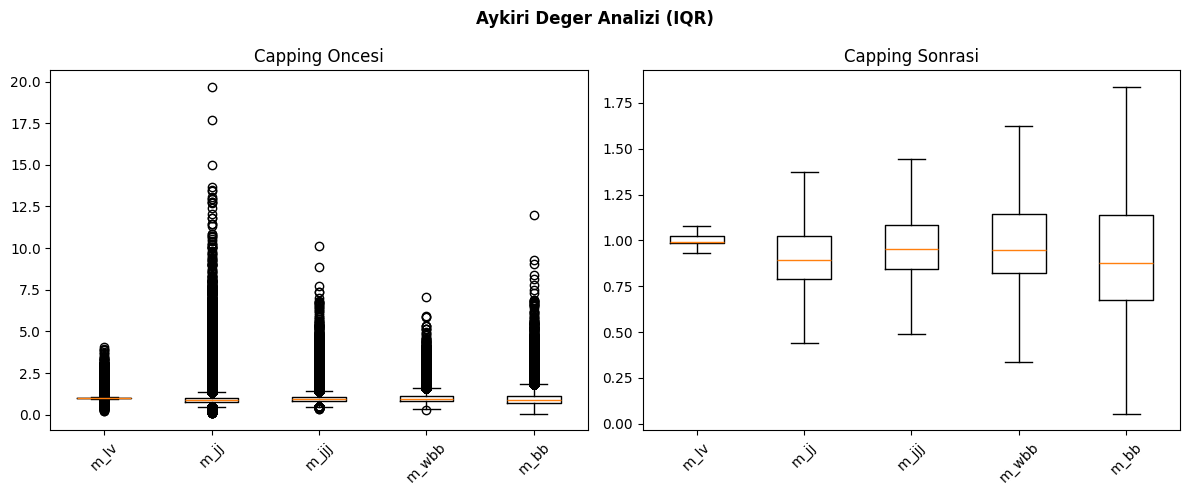

In [8]:
enc = rapor_df.head(5)['feature'].tolist()
ham = veri_yukle(N_SAMPLES, HIGGS_PATH, SEED)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].boxplot([ham[c] for c in enc], labels=enc)
ax[0].set_title('Capping Oncesi')
ax[1].boxplot([df[c] for c in enc], labels=enc)
ax[1].set_title('Capping Sonrasi')
for a in ax:
    a.tick_params(axis='x', rotation=45)
fig.suptitle('Aykiri Deger Analizi (IQR)', weight='bold')
fig.tight_layout()
fig.savefig('results/figures/outliers_boxplot.png', dpi=140)
plt.show()

---
## Bölüm 2 — Öznitelik Seçimi (ANOVA F-score, en iyi 15)

In [9]:
X = df[FEATURES].values
y = df['label'].values

Xs      = MinMaxScaler().fit_transform(X)
f_skor, _ = f_classif(Xs, y)
mi_skor   = mutual_info_classif(Xs, y, random_state=SEED)

siralama = pd.DataFrame({
    'feature'    : FEATURES,
    'anova_f'    : f_skor,
    'mutual_info': mi_skor,
}).sort_values('anova_f', ascending=False)

siralama.round(5).to_csv('results/tables/feature_ranking.csv', index=False)
top15 = siralama.head(15)['feature'].tolist()
print('Secilen 15 ozellik:', top15)
siralama.round(3)

Secilen 15 ozellik: ['m_bb', 'm_wwbb', 'missing_energy_magnitude', 'm_wbb', 'jet1_pt', 'jet2_b_tag', 'jet4_pt', 'lepton_pT', 'm_jjj', 'jet3_b_tag', 'jet4_b_tag', 'jet2_pt', 'm_lv', 'm_jj', 'jet1_b_tag']


,feature,anova_f,mutual_info
25,m_bb,1970.612,0.050
27,m_wwbb,1904.879,0.021
3,missing_energy_magnitude,792.394,0.006
26,m_wbb,455.583,0.022
5,jet1_pt,319.323,0.003
12,jet2_b_tag,270.987,0.003
17,jet4_pt,143.408,0.004
0,lepton_pT,112.494,0.005
22,m_jjj,60.325,0.015
16,jet3_b_tag,40.951,0.004


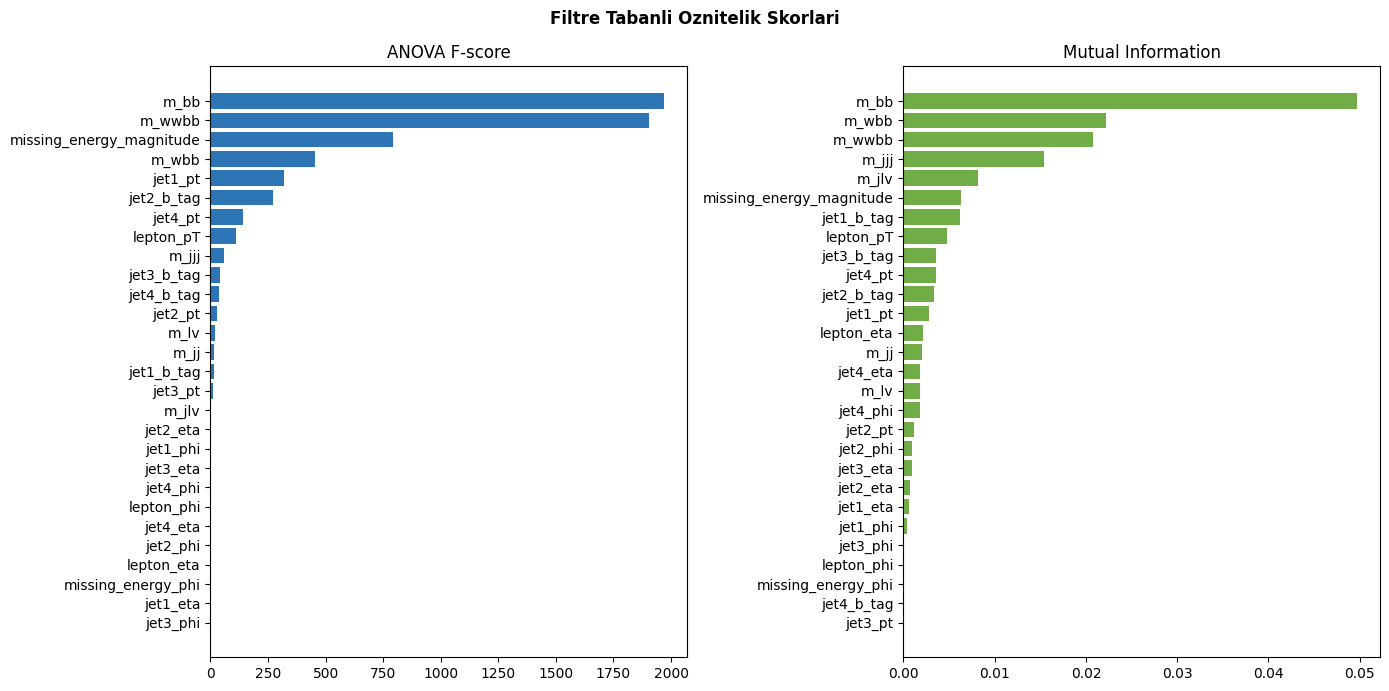

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
r1 = siralama.sort_values('anova_f')
ax[0].barh(r1['feature'], r1['anova_f'], color='#2e75b6')
ax[0].set_title('ANOVA F-score')
r2 = siralama.sort_values('mutual_info')
ax[1].barh(r2['feature'], r2['mutual_info'], color='#70ad47')
ax[1].set_title('Mutual Information')
fig.suptitle('Filtre Tabanli Oznitelik Skorlari', weight='bold')
fig.tight_layout()
fig.savefig('results/figures/feature_scores.png', dpi=140)
plt.show()

---
## Bölüm 3 — Nested Cross-Validation (GPU)

**Pipeline:** MinMax → SelectKBest(k) → Model  
**İç döngü** (3-fold GridSearchCV, `n_jobs=1`): CUDA + çoklu işlem uyumsuzluğu nedeniyle sıralı  
**Dış döngü** (5-fold): tarafsız test AUC

> XGBoost kendi içinde GPU paralelliğini yönetir. PyTorch MLP her fit için GPU'yu tam kullanır.

In [11]:
# Hiperparametre gridleri — odev gereksinimlerine gore:
#   KNN: n_neighbors = 3..11
#   SVM: C = [0.1, 1, 10], kernel = [linear, rbf]
#   MLP: hidden_layer_sizes = [(50,), (100,)], activation = [relu, tanh]
#   XGBoost: serbest (odevde aralik belirtilmemis)
# Ayrica her modelde SelectKBest(k) ic CV'de denenir (Flowchart A: oznitelik kombinasyonu).
modeller = {
    'XGBoost': (
        XGBClassifier(
            device='cuda',
            tree_method='hist',
            eval_metric='logloss',
            verbosity=0,
            random_state=SEED,
        ),
        {
            'select__k'           : K_GRID,
            'clf__n_estimators'   : [100, 200],
            'clf__max_depth'      : [4, 6],
            'clf__learning_rate'  : [0.1],
            'clf__subsample'      : [0.8],
            'clf__colsample_bytree': [0.8],
        }
    ),
    'MLP': (
        TorchMLP(batch_size=256, epochs=10, patience=3, verbose=False),
        {
            'select__k'        : K_GRID,
            'clf__hidden_sizes': [(50,), (100,)],
            'clf__activation'  : ['relu', 'tanh'],
            'clf__lr'          : [1e-3],
            'clf__dropout'     : [0.3],
        }
    ),
    'KNN': (
        KNeighborsClassifier(n_jobs=-1),
        {
            'select__k'        : K_GRID,
            'clf__n_neighbors' : [3, 5, 7, 9, 11],
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=SEED),
        {
            'select__k'  : K_GRID,
            'clf__C'     : [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
        }
    ),
}

# KNN ve SVM, O(n^2)+ karmasiklikari nedeniyle daha kucuk bir alt-orneklem uzerinde calisir.
KUCUK_ORNEKLEM_MODELLER = {'KNN', 'SVM'}

print('Model grid boyutlari:')
for ad, (_, g) in modeller.items():
    n = 1
    for v in g.values():
        n *= len(v)
    print(f'  {ad}: {n} kombo x {INNER} ic fold x {OUTER} dis fold = {n*INNER*OUTER} fit')

Model grid boyutlari:
  XGBoost: 8 kombo x 3 ic fold x 5 dis fold = 120 fit
  MLP: 8 kombo x 3 ic fold x 5 dis fold = 120 fit
  KNN: 10 kombo x 3 ic fold x 5 dis fold = 150 fit
  SVM: 12 kombo x 3 ic fold x 5 dis fold = 180 fit


In [12]:
os.makedirs('results/checkpoints', exist_ok=True)

dis = StratifiedKFold(OUTER, shuffle=True, random_state=SEED)
ozet, fold_kayit, oof = [], [], {}
renk = ['#1f4e79', '#e07b39', '#70ad47', '#2e75b6']

best_auc_global = 0.0
best_info_global = {}

for ad, (est, grid) in modeller.items():
    print(f'\n{"="*55}')
    print(f'>>> {ad} basliyor...')
    print(f'{"="*55}')
    t_model = time.time()
    sonuc, oof_y, oof_s = [], [], []

    if ad in KUCUK_ORNEKLEM_MODELLER and len(X) > KNN_SVM_N_SAMPLES:
        secim, _ = train_test_split(
            np.arange(len(X)), train_size=KNN_SVM_N_SAMPLES,
            stratify=y, random_state=SEED)
        X_ad, y_ad = X[secim], y[secim]
        print(f'  [bilgi] {ad} icin alt-orneklem: {len(X_ad)} (tam veri: {len(X)})')
    else:
        X_ad, y_ad = X, y

    dis_ad = dis if X_ad is X else StratifiedKFold(OUTER, shuffle=True, random_state=SEED)

    for k, (tr, te) in enumerate(dis_ad.split(X_ad, y_ad), 1):
        pipe = Pipeline([
            ('scaler', MinMaxScaler()),
            ('select', SelectKBest(f_classif)),
            ('clf',    est),
        ])
        ic = StratifiedKFold(INNER, shuffle=True, random_state=SEED)
        gs = GridSearchCV(pipe, grid, scoring=AUC_SCORER, cv=ic, n_jobs=1)
        gs.fit(X_ad[tr], y_ad[tr])

        iyi  = gs.best_estimator_
        skor = skor_al(iyi, X_ad[te])
        m    = metrikler(y_ad[te], iyi.predict(X_ad[te]), skor)
        m.update(fold=k, model=ad, secilen_k=gs.best_params_['select__k'],
                 gecen_sure=round(time.time() - t0, 1))
        sonuc.append(m)
        fold_kayit.append(m)
        oof_y.extend(y_ad[te])
        oof_s.extend(skor)

        pd.DataFrame(fold_kayit).round(4).to_csv('results/tables/nested_cv_perfold.csv', index=False)

        yeni_en_iyi = m['roc_auc'] > best_auc_global
        if yeni_en_iyi:
            best_auc_global = m['roc_auc']
            best_info_global = {'model': ad, 'fold': k, 'params': gs.best_params_}
            joblib.dump(
                {'model': iyi, 'features': FEATURES, 'model_adi': ad,
                 'fold': k, 'roc_auc': m['roc_auc'], 'params': gs.best_params_},
                'model.joblib'
            )

        flag = f'  <<< YENİ EN IYI KAYDEDILDI  (AUC={best_auc_global:.4f})' if yeni_en_iyi else ''
        print(f'  fold {k}/{OUTER} | {ad:8s} | k={m["secilen_k"]:2d} | '
              f'AUC={m["roc_auc"]:.4f} | F1={m["f1"]:.4f} | '
              f'{m["gecen_sure"]:.0f}s gecti{flag}')

    sd = pd.DataFrame(sonuc)
    model_ozet = {
        'model': ad,
        **{f'{met}_mean': sd[met].mean() for met in ['accuracy','precision','recall','f1','roc_auc']},
        **{f'{met}_std' : sd[met].std()  for met in ['accuracy','precision','recall','f1','roc_auc']},
    }
    ozet.append(model_ozet)
    oof[ad] = (np.array(oof_y), np.array(oof_s))

    ckpt_path = f'results/checkpoints/{ad}_checkpoint.joblib'
    joblib.dump(
        {'model': iyi, 'features': FEATURES, 'model_adi': ad,
         'roc_auc_mean': model_ozet['roc_auc_mean']},
        ckpt_path
    )
    pd.DataFrame(ozet).round(4).to_csv('results/tables/model_summary.csv', index=False)

    sure_model = time.time() - t_model
    print(f'\n  {ad} TAMAMLANDI | {sure_model/60:.1f} dk | '
          f'AUC_mean={model_ozet["roc_auc_mean"]:.4f} +/- {model_ozet["roc_auc_std"]:.4f}')
    print(f'  Checkpoint: {ckpt_path}')

print(f'\n  Simdilik EN IYI: {best_info_global.get("model","?")} '
      f'fold={best_info_global.get("fold","?")} AUC={best_auc_global:.4f}')

ozet_df = pd.DataFrame(ozet).sort_values('roc_auc_mean', ascending=False)
ozet_df.round(4).to_csv('results/tables/model_summary.csv', index=False)

print()
print('=== Ozet (ROC-AUC sirasiyla) ===')
ozet_df[['model','accuracy_mean','f1_mean','roc_auc_mean','roc_auc_std']].round(4)


>>> XGBoost basliyor...


  fold 1/5 | XGBoost  | k=15 | AUC=0.7997 | F1=0.7360 | 55s gecti  <<< YENİ EN IYI KAYDEDILDI  (AUC=0.7997)


  fold 2/5 | XGBoost  | k=15 | AUC=0.7945 | F1=0.7341 | 80s gecti


  fold 3/5 | XGBoost  | k=15 | AUC=0.8010 | F1=0.7397 | 111s gecti  <<< YENİ EN IYI KAYDEDILDI  (AUC=0.8010)


  fold 4/5 | XGBoost  | k=15 | AUC=0.7891 | F1=0.7297 | 150s gecti


...

  fold 2/5 | SVM      | k=10 | AUC=0.7211 | F1=0.6842 | 1616s gecti


  fold 3/5 | SVM      | k=10 | AUC=0.6992 | F1=0.6854 | 1622s gecti


  fold 4/5 | SVM      | k=10 | AUC=0.6738 | F1=0.6429 | 1627s gecti


  fold 5/5 | SVM      | k=10 | AUC=0.7037 | F1=0.6943 | 1632s gecti

  SVM TAMAMLANDI | 0.4 dk | AUC_mean=0.7032 +/- 0.0188
  Checkpoint: results/checkpoints/SVM_checkpoint.joblib

  Simdilik EN IYI: XGBoost fold=3 AUC=0.8010

=== Ozet (ROC-AUC sirasiyla) ===


,model,accuracy_mean,f1_mean,roc_auc_mean,roc_auc_std
0,XGBoost,0.7214,0.7356,0.7967,0.0049
1,MLP,0.6978,0.7251,0.7637,0.0047
3,SVM,0.6400,0.6783,0.7032,0.0188
2,KNN,0.6095,0.6642,0.6480,0.0214


### Metrik Karşılaştırma

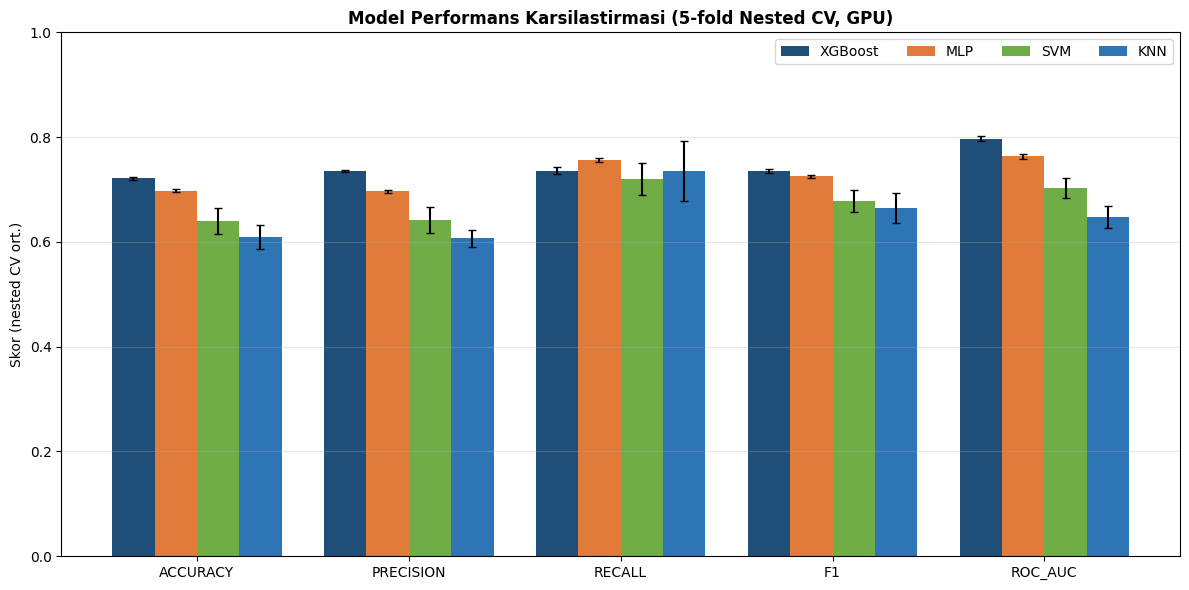

In [13]:
mets = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
xpos = np.arange(len(mets))
w    = 0.8 / len(ozet_df)

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(ozet_df.iterrows()):
    ax.bar(xpos + i * w,
           [row[f'{m}_mean'] for m in mets], w,
           yerr=[row[f'{m}_std'] for m in mets],
           capsize=3, label=row['model'], color=renk[i % len(renk)])
ax.set_xticks(xpos + w * (len(ozet_df) - 1) / 2)
ax.set_xticklabels([m.upper() for m in mets])
ax.set_ylim(0, 1)
ax.set_ylabel('Skor (nested CV ort.)')
ax.set_title('Model Performans Karsilastirmasi (5-fold Nested CV, GPU)', weight='bold')
ax.legend(ncol=len(ozet_df))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('results/figures/metric_comparison.png', dpi=140)
plt.show()

---
## ROC Eğrileri

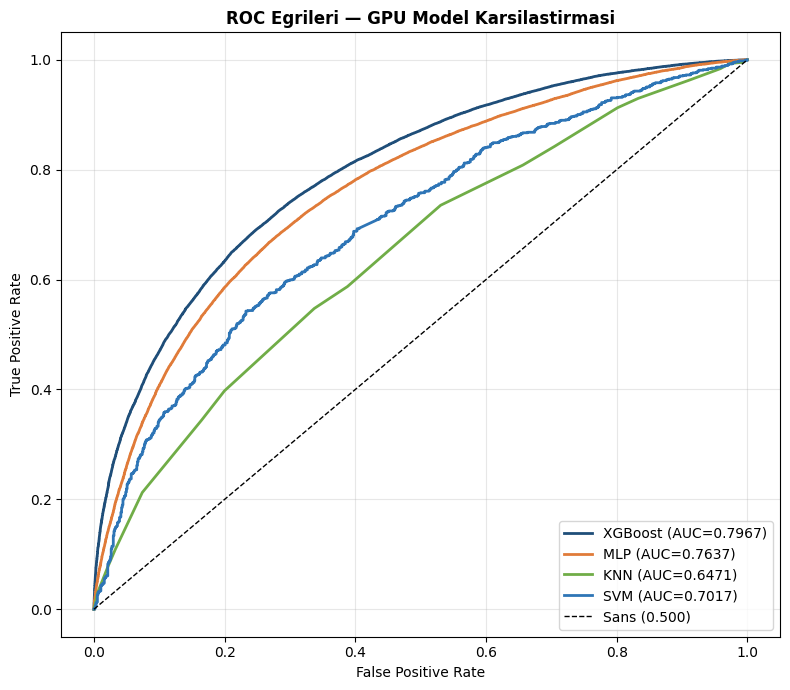

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
for (ad, (yy, ss)), col in zip(oof.items(), renk):
    fpr, tpr, _ = roc_curve(yy, ss)
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f'{ad} (AUC={roc_auc_score(yy, ss):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Sans (0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Egrileri — GPU Model Karsilastirmasi', weight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('results/figures/roc_all_models.png', dpi=140)
plt.show()

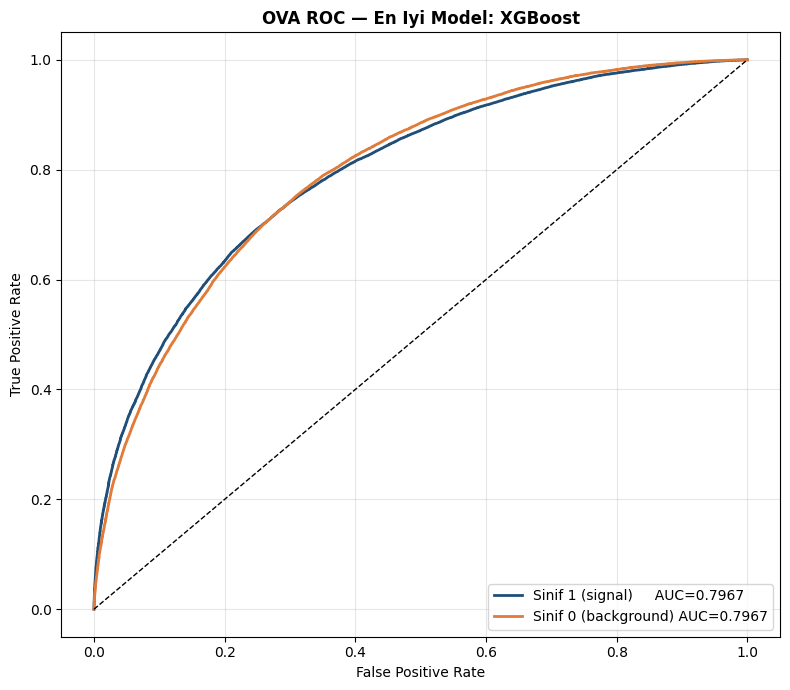

In [15]:
en_iyi = ozet_df.iloc[0]['model']
yy, ss = oof[en_iyi]

f1_, t1_, _ = roc_curve(yy, ss);     a1 = roc_auc_score(yy, ss)
f0_, t0_, _ = roc_curve(1 - yy, -ss); a0 = roc_auc_score(1 - yy, -ss)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(f1_, t1_, color='#1f4e79', lw=2, label=f'Sinif 1 (signal)     AUC={a1:.4f}')
ax.plot(f0_, t0_, color='#e07b39', lw=2, label=f'Sinif 0 (background) AUC={a0:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'OVA ROC — En Iyi Model: {en_iyi}', weight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('results/figures/roc_ova_best.png', dpi=140)
plt.show()

---
## En İyi Modeli Kaydet

Tüm veri üzerinde final GridSearch — `model.joblib` kaydedilir, `tahmin.ipynb` bunu kullanır.

In [16]:
print(f'En iyi model: {en_iyi} — tum veriyle yeniden egitiliyor...')
est, grid = modeller[en_iyi]
pipe_final = Pipeline([
    ('scaler', MinMaxScaler()),
    ('select', SelectKBest(f_classif)),
    ('clf',    est),
])
final = GridSearchCV(pipe_final, grid, scoring=AUC_SCORER,
                     cv=StratifiedKFold(INNER, shuffle=True, random_state=SEED),
                     n_jobs=1)
final.fit(X, y)

joblib.dump(
    {'model': final.best_estimator_, 'features': FEATURES, 'model_adi': en_iyi},
    'model.joblib'
)
print('Kaydedildi -> model.joblib')
print('En iyi parametreler:', final.best_params_)

En iyi model: XGBoost — tum veriyle yeniden egitiliyor...


Kaydedildi -> model.joblib
En iyi parametreler: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'select__k': 15}


In [17]:
sure = round(time.time() - t0, 1)

json.dump({
    'n_samples'              : N_SAMPLES,
    'is_synthetic'           : not os.path.exists(HIGGS_PATH),
    'device'                 : DEVICE,
    'selected_features_top15': top15,
    'model_summary'          : ozet_df.round(4).to_dict(orient='records'),
    'best_model'             : en_iyi,
    'best_params'            : {k: str(v) for k, v in final.best_params_.items()},
    'outer'                  : OUTER,
    'inner'                  : INNER,
    'k_grid'                 : K_GRID,
    'class_balance'          : df['label'].value_counts(normalize=True).round(4).to_dict(),
    'runtime_sec'            : sure,
}, open('results/summary.json', 'w'), indent=2, ensure_ascii=False)

print('=' * 60)
print(f'BITTI | sure={sure:.0f}s ({sure/60:.1f} dk) | En iyi: {en_iyi} | Device: {DEVICE}')
print('=' * 60)

BITTI | sure=1644s (27.4 dk) | En iyi: XGBoost | Device: cuda
